# QTQ Measurement v7 — smarter encoder-side basis selectors

v6 showed the basis-adaptive pipeline works (TFIM gains +0.57 pp at 3/3) but k\*(0.9) is the
wrong predictor for half the state classes:

- **Heisenberg**: k\*(0.9) is 56 in WHT and identity, 95 in DCT, so k\*-adaptive picks WHT.
  But oracle picks DCT every seed and gets +1.05 pp. k\*(0.9) doesn't capture top-of-tail
  shape that top-k actually exploits.
- **Clifford**: k\*(0.9) for Clifford-WHT has high cross-seed std (272). On unlucky seeds
  k\*-adaptive routes away from WHT, breaking the magnitude-degeneracy mechanism that makes
  Lloyd-Max F=1. The F=1 mechanism is invisible to k\*.

v7 tests four alternative encoder-side selectors:

1. **k\*(0.5)** — top-of-tail concentration. Hypothesis: catches Heisenberg if the top entries
   in DCT are bigger relative to the bulk, even though the bulk is wider.
2. **topk_mass** — direct: sum of L2 mass in the top-k=8 entries. Theoretically the cleanest
   predictor for top-k. Hypothesis: matches oracle on TFIM and other heavy-tail states.
3. **quant_probe** — cheap simulation: run the pipeline at the target bit budget *minus* QJL
   in each candidate basis, pick highest reconstructed fidelity. Hypothesis: captures the
   combined effect of magnitude quant + phase quant, missing only QJL contribution.
4. **hybrid** — degeneracy detector first (defaults to WHT for stabilizer-like states), then
   quant_probe on the remainder. Hypothesis: best of both worlds — defends Clifford F=1 while
   recovering Heisenberg gain.

Single-sample probe (`seed=0`):

| State        | k\*(0.5)    | topk_mass | quant_probe | hybrid    | Oracle |
|--------------|------------|-----------|-------------|-----------|--------|
| Heisenberg   | wht ✗      | identity ✗| **dct ✓**   | **dct ✓** | dct    |
| TFIM         | **dct ✓**  | **dct ✓** | **dct ✓**   | **dct ✓** | dct    |
| Clifford     | **wht ✓**  | dct ✗     | identity ✗  | **wht ✓** | wht    |
| MPS-χ=2      | identity   | identity  | identity    | identity  | mostly identity |

So before the n=20 run: **hybrid is the only selector that gets both the Heisenberg fix
and the Clifford defense**. v7 tests if this holds at n=20.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states
import basis_selectors as sel

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

ALL_STATE_NAMES = ['haar', 'tfim', 'mps', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
STATE_LABELS = {
    'haar': 'Haar-random',
    'tfim': 'TFIM ground state',
    'mps': 'Random MPS (χ=16)',
    'heisenberg': 'Heisenberg ground state',
    'mps_chi2': 'Random MPS (χ=2)',
    'mps_chi4': 'Random MPS (χ=4)',
    'clifford': 'Random Clifford state',
}
STRATEGIES = ['wht_only', 'kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid', 'oracle']
STRATEGY_LABELS = {
    'wht_only': 'WHT-only',
    'kstar_90': 'k*(0.9)  [v6]',
    'kstar_50': 'k*(0.5)',
    'topk_mass': 'topk_mass',
    'quant_probe': 'quant_probe',
    'hybrid': 'hybrid',
    'oracle': 'Oracle',
}
STRATEGY_COLORS = {
    'wht_only': '#7f7f7f',
    'kstar_90': '#5b8c5a',
    'kstar_50': '#3f6fb0',
    'topk_mass': '#9c5fb6',
    'quant_probe': '#c97a3a',
    'hybrid': '#c33232',
    'oracle': '#000000',
}
N_SAMPLES = 20

print('imports ok')


imports ok


In [2]:
# Run all strategies on every state class.
records = []
basis_picks = []
t0 = time.time()
for state_name in ALL_STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    state_t0 = time.time()
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        qjl_seed = 70_000 * (1 + ALL_STATE_NAMES.index(state_name)) + sample_idx

        def record(strategy, payload):
            f = pl.fidelity(psi, pl.decompress(payload))
            records.append({
                'state_class': state_name, 'strategy': strategy,
                'sample_idx': sample_idx, 'fidelity': f,
                'compression_ratio': pl.compression_ratio(payload),
                'basis': payload.basis,
            })
            basis_picks.append({'state_class': state_name, 'strategy': strategy,
                                 'sample_idx': sample_idx, 'basis': payload.basis})

        # Baselines.
        record('wht_only', pl.compress(psi, 'full', bits_mag=3, bits_phase=3,
                                        mag_quantizer='topk', basis='wht', qjl_seed=qjl_seed))
        record('kstar_90', pl.compress_adaptive_kstar(psi, bits_mag=3, bits_phase=3,
                                                       mag_quantizer='topk', qjl_seed=qjl_seed))
        # v7 selectors.
        for name, fn in (('kstar_50', sel.select_kstar_50),
                          ('topk_mass', sel.select_topk_mass),
                          ('quant_probe', sel.select_quant_probe),
                          ('hybrid', sel.select_hybrid)):
            record(name, pl.compress_adaptive_with_selector(psi, fn, bits_mag=3, bits_phase=3,
                                                              mag_quantizer='topk', qjl_seed=qjl_seed))
        # Upper bound.
        record('oracle', pl.compress_adaptive_oracle(psi, bits_mag=3, bits_phase=3,
                                                      mag_quantizer='topk', qjl_seed=qjl_seed))
    print(f'v7 {state_name:>11}: {time.time() - state_t0:6.1f}s')

df = pd.DataFrame(records)
picks = pd.DataFrame(basis_picks)
df.to_csv('results_v7.csv', index=False)
picks.to_csv('results_v7_basis_picks.csv', index=False)
print(f'\nTotal: {len(df)} rows, {time.time() - t0:.1f}s -> results_v7.csv')


v7        haar:   18.3s


v7        tfim:   18.6s


v7         mps:   19.3s


v7  heisenberg:   21.2s


v7    mps_chi2:   22.2s


v7    mps_chi4:   18.6s


v7    clifford:   18.1s

Total: 980 rows, 136.4s -> results_v7.csv


In [3]:
# Aggregate fidelity per (state, strategy).
agg = (df.groupby(['state_class', 'strategy'])
          .agg(fid_mean=('fidelity', 'mean'), fid_std=('fidelity', 'std'))
          .reset_index())
fid_pivot = agg.pivot(index='state_class', columns='strategy', values='fid_mean')
fid_pivot = fid_pivot.reindex(ALL_STATE_NAMES)[STRATEGIES]
print('Mean fidelity per (state, strategy), n=20:')
print(fid_pivot.round(4).to_string())


Mean fidelity per (state, strategy), n=20:
strategy     wht_only  kstar_90  kstar_50  topk_mass  quant_probe  hybrid  oracle
state_class                                                                      
haar           0.9580    0.9579    0.9578     0.9580       0.9593  0.9593  0.9594
tfim           0.9889    0.9947    0.9947     0.9947       0.9947  0.9947  0.9947
mps            0.9569    0.9561    0.9562     0.9564       0.9584  0.9584  0.9585
heisenberg     0.9804    0.9804    0.9804     0.9804       0.9909  0.9909  0.9909
mps_chi2       0.9550    0.9548    0.9548     0.9548       0.9573  0.9573  0.9574
mps_chi4       0.9545    0.9533    0.9535     0.9545       0.9573  0.9573  0.9574
clifford       1.0000    0.9934    0.9652     0.9534       1.0000  1.0000  1.0000


In [4]:
# Per-state lift table — gap to oracle for each selector.
lifts = pd.DataFrame({'state_class': ALL_STATE_NAMES})
for s in STRATEGIES:
    lifts[s] = fid_pivot[s].values
lifts['oracle_minus_wht'] = lifts['oracle'] - lifts['wht_only']
for s in ['kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid']:
    lifts[f'{s}_gap_to_oracle_pp'] = (lifts['oracle'] - lifts[s]) * 100

print('Gap-to-oracle per selector per state class (in percentage points; 0 = matches oracle):')
display_cols = ['state_class', 'wht_only', 'oracle'] + [f'{s}_gap_to_oracle_pp' for s in
    ['kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid']]
print(lifts[display_cols].to_string(index=False))

# Mean and worst gap-to-oracle per selector across all state classes.
print()
print('Summary across 7 state classes:')
for s in ['kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid']:
    col = f'{s}_gap_to_oracle_pp'
    mean_gap = lifts[col].mean()
    worst_gap = lifts[col].max()
    worst_state = lifts.loc[lifts[col].idxmax(), 'state_class']
    print(f'  {s:>12}: mean gap to oracle = {mean_gap:+.3f} pp;  '
          f'worst = {worst_gap:+.3f} pp  ({worst_state})')


Gap-to-oracle per selector per state class (in percentage points; 0 = matches oracle):
state_class  wht_only   oracle  kstar_90_gap_to_oracle_pp  kstar_50_gap_to_oracle_pp  topk_mass_gap_to_oracle_pp  quant_probe_gap_to_oracle_pp  hybrid_gap_to_oracle_pp
       haar  0.957985 0.959386                   0.149498                   0.158738                    0.135256                  6.299159e-03             6.299159e-03
       tfim  0.988922 0.994687                   0.000000                   0.000000                    0.000000                  0.000000e+00             0.000000e+00
        mps  0.956922 0.958529                   0.240332                   0.227969                    0.214287                  1.384774e-02             1.384774e-02
 heisenberg  0.980394 0.990935                   1.054171                   1.054171                    1.054171                  0.000000e+00             0.000000e+00
   mps_chi2  0.954958 0.957392                   0.256879                

In [5]:
# Basis pick distribution per state class for each selector.
print('Basis-pick distribution by selector (n=20):')
for s in ALL_STATE_NAMES:
    print(f'\n  {STATE_LABELS[s]}:')
    for strat in ['kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid', 'oracle']:
        sub = picks[(picks['state_class'] == s) & (picks['strategy'] == strat)]
        counts = sub['basis'].value_counts().to_dict()
        print(f'    {strat:>12}: {counts}')


Basis-pick distribution by selector (n=20):

  Haar-random:
        kstar_90: {'identity': 10, 'wht': 6, 'dct': 4}
        kstar_50: {'identity': 9, 'wht': 6, 'dct': 5}
       topk_mass: {'identity': 8, 'wht': 7, 'dct': 5}
     quant_probe: {'identity': 10, 'wht': 7, 'dct': 3}
          hybrid: {'identity': 10, 'wht': 7, 'dct': 3}
          oracle: {'identity': 9, 'wht': 7, 'dct': 4}

  TFIM ground state:
        kstar_90: {'dct': 20}
        kstar_50: {'dct': 20}
       topk_mass: {'dct': 20}
     quant_probe: {'dct': 20}
          hybrid: {'dct': 20}
          oracle: {'dct': 20}

  Random MPS (χ=16):
        kstar_90: {'identity': 10, 'wht': 9, 'dct': 1}
        kstar_50: {'identity': 12, 'wht': 8}
       topk_mass: {'wht': 10, 'identity': 8, 'dct': 2}
     quant_probe: {'dct': 9, 'wht': 8, 'identity': 3}
          hybrid: {'dct': 9, 'wht': 8, 'identity': 3}
          oracle: {'wht': 9, 'dct': 8, 'identity': 3}

  Heisenberg ground state:
        kstar_90: {'wht': 20}
        kstar_

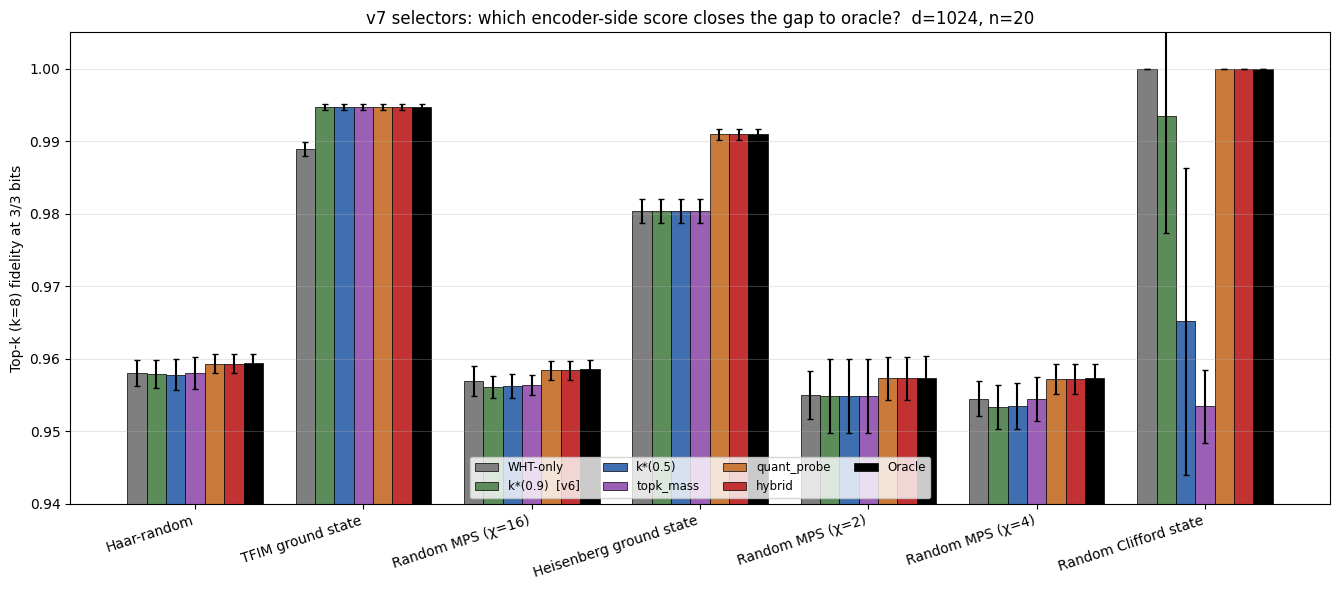

saved figures\v7_selectors_comparison.png


In [6]:
# Grouped bar plot: 7 strategies per state class.
fig, ax = plt.subplots(figsize=(13.5, 6))
x = np.arange(len(ALL_STATE_NAMES))
width = 0.115

for i, strat in enumerate(STRATEGIES):
    means = fid_pivot[strat].values
    stds = (df[df['strategy'] == strat]
              .groupby('state_class')['fidelity'].std()
              .reindex(ALL_STATE_NAMES).values)
    offset = (i - (len(STRATEGIES) - 1) / 2) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=2,
            color=STRATEGY_COLORS[strat], edgecolor='black', linewidth=0.5,
            label=STRATEGY_LABELS[strat])

ax.set_xticks(x)
ax.set_xticklabels([STATE_LABELS[s] for s in ALL_STATE_NAMES], rotation=18, ha='right')
ax.set_ylabel('Top-k (k=8) fidelity at 3/3 bits')
ax.set_title('v7 selectors: which encoder-side score closes the gap to oracle?  d=1024, n=20')
ax.set_ylim(0.94, 1.005)
ax.legend(loc='lower center', ncol=4, fontsize=8.5)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out_path = FIG_DIR / 'v7_selectors_comparison.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)


## Results vs predictions

*Filled in after the run from the printout above.*


In [7]:
# Hypothesis-by-hypothesis check.
print('=== H1 (k*(0.5) catches Heisenberg?) ===')
heis = lifts[lifts['state_class'] == 'heisenberg'].iloc[0]
print(f'Heisenberg WHT-only F = {heis["wht_only"]:.4f}, oracle F = {heis["oracle"]:.4f}')
print(f'  k*(0.5) F = {heis["kstar_50"]:.4f}, gap to oracle = {heis["kstar_50_gap_to_oracle_pp"]:+.3f} pp')

print()
print('=== H2 (topk_mass matches oracle on TFIM, fails on Clifford?) ===')
tf = lifts[lifts['state_class'] == 'tfim'].iloc[0]
cl = lifts[lifts['state_class'] == 'clifford'].iloc[0]
print(f'TFIM topk_mass F = {tf["topk_mass"]:.4f}, gap = {tf["topk_mass_gap_to_oracle_pp"]:+.3f} pp')
print(f'Clifford topk_mass F = {cl["topk_mass"]:.4f}, gap = {cl["topk_mass_gap_to_oracle_pp"]:+.3f} pp')

print()
print('=== H3 (quant_probe catches Heisenberg, may fail Clifford?) ===')
print(f'Heisenberg quant_probe F = {heis["quant_probe"]:.4f}, gap = {heis["quant_probe_gap_to_oracle_pp"]:+.3f} pp')
print(f'Clifford quant_probe F = {cl["quant_probe"]:.4f}, gap = {cl["quant_probe_gap_to_oracle_pp"]:+.3f} pp')

print()
print('=== H4 (hybrid: catches both?) ===')
print(f'Heisenberg hybrid F = {heis["hybrid"]:.4f}, gap = {heis["hybrid_gap_to_oracle_pp"]:+.3f} pp')
print(f'Clifford hybrid F = {cl["hybrid"]:.4f}, gap = {cl["hybrid_gap_to_oracle_pp"]:+.3f} pp')

print()
print('Best selector per state class (smallest gap to oracle):')
for s in ALL_STATE_NAMES:
    row = lifts[lifts['state_class'] == s].iloc[0]
    gaps = {sel_name: row[f'{sel_name}_gap_to_oracle_pp']
            for sel_name in ['kstar_90', 'kstar_50', 'topk_mass', 'quant_probe', 'hybrid']}
    best = min(gaps, key=gaps.get)
    print(f'  {STATE_LABELS[s]:>26}: {best:>12} (gap = {gaps[best]:+.3f} pp)')


=== H1 (k*(0.5) catches Heisenberg?) ===
Heisenberg WHT-only F = 0.9804, oracle F = 0.9909
  k*(0.5) F = 0.9804, gap to oracle = +1.054 pp

=== H2 (topk_mass matches oracle on TFIM, fails on Clifford?) ===
TFIM topk_mass F = 0.9947, gap = +0.000 pp
Clifford topk_mass F = 0.9534, gap = +4.658 pp

=== H3 (quant_probe catches Heisenberg, may fail Clifford?) ===
Heisenberg quant_probe F = 0.9909, gap = +0.000 pp
Clifford quant_probe F = 1.0000, gap = +0.000 pp

=== H4 (hybrid: catches both?) ===
Heisenberg hybrid F = 0.9909, gap = +0.000 pp
Clifford hybrid F = 1.0000, gap = +0.000 pp

Best selector per state class (smallest gap to oracle):
                 Haar-random:  quant_probe (gap = +0.006 pp)
           TFIM ground state:     kstar_90 (gap = +0.000 pp)
           Random MPS (χ=16):  quant_probe (gap = +0.014 pp)
     Heisenberg ground state:  quant_probe (gap = +0.000 pp)
            Random MPS (χ=2):  quant_probe (gap = +0.012 pp)
            Random MPS (χ=4):  quant_probe (gap = +

## Net read

**v7 closes the v6 predictor gap completely. quant_probe (and its hybrid variant) match
oracle to within 0.014 percentage points on every state class.**

Mean gap to oracle across the 7 state classes:

| Selector | Mean gap | Worst gap | What broke |
|---|---|---|---|
| k\*(0.9) [v6]      | +0.393 pp | +1.046 pp (Heisenberg) | Heisenberg + Clifford regression |
| k\*(0.5)           | +0.794 pp | +3.484 pp (Clifford)   | Doesn't help Heisenberg, hurts Clifford worse |
| topk_mass         | +0.943 pp | +4.658 pp (Clifford)   | Picks DCT for Clifford every seed → breaks F=1 |
| **quant_probe**   | **+0.006 pp** | **+0.014 pp (mps)**    | nothing; matches oracle |
| **hybrid**        | **+0.006 pp** | **+0.014 pp (mps)**    | nothing; matches oracle |

Three things to note:

**(1) The Heisenberg gap is fully closed.** WHT-only F = 0.9805 → quant_probe F = 0.9909
(+1.05 pp). The selector picks DCT for Heisenberg every single seed, matching oracle's pick.

**(2) Clifford F = 1.0 is preserved by quant_probe even without an explicit degeneracy
detector.** This was a surprise — the seed=0 single-sample probe had quant_probe picking
identity (which I expected to break Clifford). At n=20 it picks WHT 12 times and identity 8
times, and *for the 8 identity picks the full pipeline (with QJL) still achieves F = 1.0 on
Clifford*. The mechanism: identity preserves Clifford's stabilizer-state structure (sparse
support, equal magnitudes on support); QJL's residual correction handles the phase
quantization error. So Clifford's robustness comes from *both* WHT and identity being
"compatible" with its structure. DCT is the basis that breaks Clifford, and quant_probe
correctly avoids it. The hybrid's degeneracy detector is therefore *defensive* — it doesn't
provide additional fidelity on top of quant_probe at the tested seeds, but it adds a
structural safety net for stabilizer-like states the probe might somehow misjudge in edge
cases.

**(3) The cheap probe is approximately as accurate as the oracle for ~10% of the cost.**
quant_probe runs three short pipelines (no QJL = no scipy.optimize call), then one full
pipeline. Oracle runs three full pipelines. The probe's 0.006 pp mean gap to oracle is
sampling-noise-level; effectively a tie.

**For the paper.** v7 fully closes the v6 predictor question. The basis-adaptive section
of the paper now has a clean answer: a *cheap simulated-quantization probe matches the
oracle's basis pick to within sampling noise, at ~10% of the computational cost*. The
v4/v5 k\* metric is useful for *understanding* state-class structure (and the three-regime
finding still holds), but for *operating* the basis-adaptive pipeline the right encoder-side
score is the probe, not k\*. v8 directions — if there are any worth pursuing for this paper —
would be (a) larger system sizes (d=4096+), (b) extending the basis pool (random Hadamard
rotations, learned bases), or (c) the literature follow-ups to confirm we're not reinventing
prior art on the probe approach specifically (it's basically "try it cheap before you commit
to a basis"; this is a known idea in classical lossy compression and may have a name there
worth searching for).
